# 0 - Setup


In [ ]:
# IMPORT LIBRARIES
!pip install pytorch-tabnet
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from pytorch_tabnet.tab_model import TabNetClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.5 MB/s eta 0:00:00


# Import Dataset

In [ ]:
# IMPORT Data set
from google.colab import drive
drive.mount('/content/drive')
# health_indicator.csv
df = pd.read_csv("/content/drive/MyDrive/Diabetes-ML-Project/data /diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
df.head()

Mounted at /content/drive


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


# 1 - Explatory Data Analysis

In [ ]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nSummary stats:")
print(df.describe())

Shape: (70692, 22)

Columns: Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

Summary stats:
       Diabetes_binary        HighBP      HighChol     CholCheck  \
count     70692.000000  70692.000000  70692.000000  70692.000000   
mean          0.500000      0.563458      0.525703      0.975259   
std           0.500004      0.495960      0.499342      0.155336   
min           0.000000      0.000000      0.000000      0.000000   
25%           0.000000      0.000000      0.000000      1.000000   
50%           0.500000      1.000000      1.000000      1.000000   
75%           1.000000      1.000000      1.000000      1.000000   
max           1.000000      1.000000      1.000000      1.000000   

     

In [ ]:
df.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


The dataset was checked for missing values using df.isnull().sum(), and no missing values were found across all features. This confirms that the dataset is complete and does not require imputation or data cleaning for missing entries.

<Axes: xlabel='Diabetes_binary', ylabel='count'>

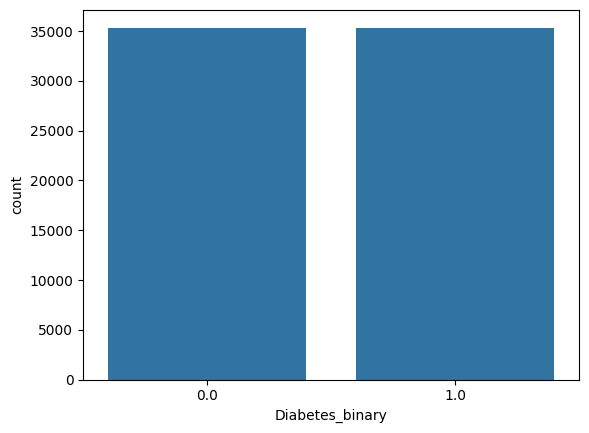

In [ ]:
sns.countplot(x="Diabetes_binary", data=df)

The dataset is balanced with an equal distribution of diabetic/prediabetic and non-diabetic individuals.

<Axes: >

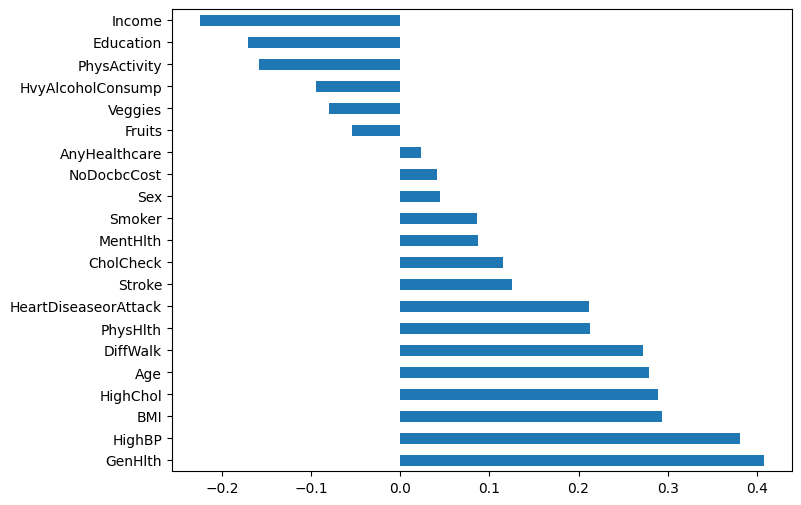

In [ ]:
corr_target = df.corr()["Diabetes_binary"].sort_values(ascending=False)

plt.figure(figsize=(8,6))
corr_target.drop("Diabetes_binary").plot(kind="barh")

Due to the high number of features, the full correlation heatmap became difficult to interpret. To improve clarity, feature correlations with the target variable were visualized separately, allowing for better identification of the most influential predictors.

The correlation analysis shows that several health-related variables are positively associated with diabetes. In particular, general health, high blood pressure, BMI, and cholesterol levels exhibit the strongest positive correlations, suggesting that individuals with poorer health conditions are more likely to have diabetes.

Conversely, socioeconomic factors such as income and education show negative correlations with diabetes, indicating that higher socioeconomic status may be associated with a lower likelihood of the condition.

Overall, the results highlight that both health indicators and lifestyle factors play a role in diabetes prevalence.

# 2 - TabNet Model

In [ ]:
X = df.drop("Diabetes_binary", axis=1).to_numpy()
y = df["Diabetes_binary"].to_numpy()

In [ ]:
# first split: train+val vs test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# second split: train vs validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1
)

#fit the model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.57628 | val_auc: 0.77399 |  0:00:07s
epoch 1  | loss: 0.53224 | val_auc: 0.8117  |  0:00:13s
epoch 2  | loss: 0.52366 | val_auc: 0.82103 |  0:00:17s
epoch 3  | loss: 0.51749 | val_auc: 0.82419 |  0:00:21s
epoch 4  | loss: 0.51496 | val_auc: 0.82625 |  0:00:27s
epoch 5  | loss: 0.5125  | val_auc: 0.82691 |  0:00:31s
epoch 6  | loss: 0.51137 | val_auc: 0.82882 |  0:00:35s
epoch 7  | loss: 0.5095  | val_auc: 0.82982 |  0:00:40s
epoch 8  | loss: 0.50877 | val_auc: 0.82914 |  0:00:45s
epoch 9  | loss: 0.51017 | val_auc: 0.82422 |  0:00:49s
epoch 10 | loss: 0.50921 | val_auc: 0.83099 |  0:00:53s
epoch 11 | loss: 0.50681 | val_auc: 0.83008 |  0:00:59s
epoch 12 | loss: 0.50714 | val_auc: 0.83063 |  0:01:03s
epoch 13 | loss: 0.50539 | val_auc: 0.83056 |  0:01:08s
epoch 14 | loss: 0.50612 | val_auc: 0.83107 |  0:01:13s
epoch 15 | loss: 0.50377 | val_auc: 0.83029 |  0:01:17s
epoch 16 | loss: 0.5052  | val_auc: 0.83021 |  0:01:21s
epoch 17 | loss: 0.50703 | val_auc: 0.83165 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


To improve performance  additional hyperparameter tuning may be explored later. Default tabnet parameters were used above.


In [ ]:
#predict
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]

In [ ]:
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.7510432138057854
Precision: 0.7274708370721702
Recall: 0.8028009619465271
F1 Score: 0.7632817753866846
ROC-AUC: 0.8275672032979423


The TabNet model demonstrated strong learning behavior, with validation AUC improving steadily across epochs and peaking at approximately 0.83 before early stopping was triggered. This indicates that the model was able to effectively learn patterns from the data while avoiding overfitting. Final evaluation results show strong recall and ROC-AUC, suggesting the model performs well in identifying diabetic cases.

Multiple evaluation metrics were used to assess model performance, including Accuracy, Precision, Recall, F1 Score, and ROC-AUC. While accuracy provides an overall measure, recall is emphasized due to the importance of correctly identifying diabetic cases.


---

Accuracy - The model correctly predicts approximately 75% of cases.


---


Precision - When the model predicts diabetes, it is correct about 73% of the time, indicating a moderate number of false positives.


---

Recall - The model correctly identifies about 80% of actual diabetic cases, meaning it misses approximately 20%.


---

F1 score - provides a balance between precision and recall. The obtained F1 score of 0.76 indicates strong and well-balanced performance, suggesting the model is effective at both identifying diabetic cases and minimizing incorrect prediction


---
ROC-AUC -  score of approximately 0.83 indicates strong model performance, demonstrating that the model is effective at distinguishing between diabetic and non-diabetic cases.

# 3 - Parameter Tuning for TabNet ( n_d, n_A )

The baseline TabNet model was trained using default parameters, reaching its best performance at epoch 17 with a validation AUC of ~0.832. Training took approximately 2 minutes and 18 seconds on CPU. On the test set, the model achieved a recall of about 0.80, meaning it correctly identifies 80% of diabetic cases.

Since this is a medical prediction task, recall is the most important metric, as missing diabetic patients (false negatives) is more critical than false positives. While the baseline performs reasonably well, improvements are needed to increase recall and reduce missed cases.

Further hyperparameter tuning (e.g., model size, learning rate, and steps) is justified to both improve performance and potentially reduce training time.See below

To ensure fair comparison across experiments, the same training, validation, and test splits were kept fixed while only TabNet hyperparameters and training settings were adjusted.

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1,
    n_d = 16,    #according to paper n_d = n_a is a reasonable choice for most datasets DEFAULT
    n_a =16,

)

#fit the model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.57562 | val_auc: 0.77639 |  0:00:05s
epoch 1  | loss: 0.53527 | val_auc: 0.80986 |  0:00:10s
epoch 2  | loss: 0.52039 | val_auc: 0.81473 |  0:00:15s
epoch 3  | loss: 0.51765 | val_auc: 0.8239  |  0:00:20s
epoch 4  | loss: 0.51403 | val_auc: 0.82713 |  0:00:25s
epoch 5  | loss: 0.51155 | val_auc: 0.82716 |  0:00:30s
epoch 6  | loss: 0.51302 | val_auc: 0.82565 |  0:00:35s
epoch 7  | loss: 0.51049 | val_auc: 0.82826 |  0:00:40s
epoch 8  | loss: 0.50968 | val_auc: 0.82761 |  0:00:45s
epoch 9  | loss: 0.50888 | val_auc: 0.82889 |  0:00:50s
epoch 10 | loss: 0.50659 | val_auc: 0.82831 |  0:00:55s
epoch 11 | loss: 0.50703 | val_auc: 0.82702 |  0:01:00s
epoch 12 | loss: 0.50778 | val_auc: 0.82917 |  0:01:05s
epoch 13 | loss: 0.50691 | val_auc: 0.83044 |  0:01:10s
epoch 14 | loss: 0.50708 | val_auc: 0.82801 |  0:01:15s
epoch 15 | loss: 0.50766 | val_auc: 0.82548 |  0:01:20s
epoch 16 | loss: 0.50846 | val_auc: 0.8262  |  0:01:25s
epoch 17 | loss: 0.50725 | val_auc: 0.8285  |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
#predict
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]

In [ ]:
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.7494872338920716
Precision: 0.7176354436628409
Recall: 0.8226057433866176
F1 Score: 0.766543633008173
ROC-AUC: 0.8265104047134499


ncreasing the hidden dimension (n_d = n_a = 16) did not improve performance compared to the baseline. Both recall and ROC-AUC decreased slightly, suggesting that the default model size is sufficient and that increasing model capacity does not benefit this dataset.

# 4 - Tuning Parameters (n_steps & gamma)

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1,
    n_steps=5,  #according to paper nsteps [3,10] is optimal when theres more info bearing features we tend to increase number of steps for now 5 is a good midpoint
    gamma = 1.5,  # according to paper typically larger nsteps value favors for a larger gamma
)

#fit the model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128

)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.59987 | val_auc: 0.76893 |  0:00:06s
epoch 1  | loss: 0.55543 | val_auc: 0.79464 |  0:00:13s
epoch 2  | loss: 0.54365 | val_auc: 0.8     |  0:00:19s
epoch 3  | loss: 0.53622 | val_auc: 0.80762 |  0:00:26s
epoch 4  | loss: 0.52787 | val_auc: 0.81369 |  0:00:32s
epoch 5  | loss: 0.52477 | val_auc: 0.81789 |  0:00:39s
epoch 6  | loss: 0.52095 | val_auc: 0.82296 |  0:00:45s
epoch 7  | loss: 0.52184 | val_auc: 0.81737 |  0:00:53s
epoch 8  | loss: 0.52402 | val_auc: 0.81819 |  0:00:59s
epoch 9  | loss: 0.51715 | val_auc: 0.82505 |  0:01:06s
epoch 10 | loss: 0.51435 | val_auc: 0.82619 |  0:01:12s
epoch 11 | loss: 0.51302 | val_auc: 0.82805 |  0:01:19s
epoch 12 | loss: 0.50929 | val_auc: 0.82942 |  0:01:26s
epoch 13 | loss: 0.50821 | val_auc: 0.83016 |  0:01:32s
epoch 14 | loss: 0.51105 | val_auc: 0.82137 |  0:01:39s
epoch 15 | loss: 0.51131 | val_auc: 0.83156 |  0:01:45s
epoch 16 | loss: 0.50854 | val_auc: 0.83035 |  0:01:52s
epoch 17 | loss: 0.50598 | val_auc: 0.8306  |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
#predict
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]

In [ ]:
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.7478605276186435
Precision: 0.7238691541017123
Recall: 0.8013863347008063
F1 Score: 0.760657938905673
ROC-AUC: 0.8259992380621568


ncreasing n_steps to 5 and gamma to 1.5, as suggested in the TabNet paper, did not improve performance compared to the baseline. Both recall and ROC-AUC decreased slightly, indicating that additional decision steps and higher feature reuse do not benefit this dataset.

# 5 - Tune Performance (batchsize )

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1,

)

#fit the model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=512,   #according to paper large batch size is beneficialabout 1-10% of the total dataset size
    virtual_batch_size=128    #according to paper virtual batch size is typically much smaller than the batch_size we will keep this the same
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.58083 | val_auc: 0.72653 |  0:00:03s
epoch 1  | loss: 0.54207 | val_auc: 0.79989 |  0:00:06s
epoch 2  | loss: 0.52956 | val_auc: 0.81445 |  0:00:09s
epoch 3  | loss: 0.52643 | val_auc: 0.81892 |  0:00:12s
epoch 4  | loss: 0.52099 | val_auc: 0.82233 |  0:00:15s
epoch 5  | loss: 0.51781 | val_auc: 0.82366 |  0:00:19s
epoch 6  | loss: 0.51665 | val_auc: 0.82503 |  0:00:22s
epoch 7  | loss: 0.51456 | val_auc: 0.82428 |  0:00:25s
epoch 8  | loss: 0.51476 | val_auc: 0.82657 |  0:00:28s
epoch 9  | loss: 0.51628 | val_auc: 0.82581 |  0:00:30s
epoch 10 | loss: 0.51267 | val_auc: 0.82804 |  0:00:34s
epoch 11 | loss: 0.51232 | val_auc: 0.8283  |  0:00:37s
epoch 12 | loss: 0.51099 | val_auc: 0.82867 |  0:00:40s
epoch 13 | loss: 0.51015 | val_auc: 0.82875 |  0:00:43s
epoch 14 | loss: 0.51256 | val_auc: 0.82922 |  0:00:46s
epoch 15 | loss: 0.5113  | val_auc: 0.82881 |  0:00:50s
epoch 16 | loss: 0.51044 | val_auc: 0.82894 |  0:00:52s
epoch 17 | loss: 0.5096  | val_auc: 0.8291  |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
#predict
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]

In [ ]:
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.7503359502086427
Precision: 0.74579802750382
Recall: 0.7595133682274721
F1 Score: 0.7525932155873283
ROC-AUC: 0.8288271319503067


Increasing the batch size to 512 resulted in a slight improvement in ROC-AUC and precision, but caused a significant decrease in recall. This indicates that larger batch sizes lead to more conservative predictions, which is not ideal for this problem where identifying diabetic cases (high recall) is the priority.

Virtual batch size was not further tuned, as increasing the overall batch size negatively impacted recall. Since virtual batch size primarily affects batch normalization behavior within larger batches, additional tuning was not pursued.

# 6 - Tune Performance (learning rate)

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1,
    optimizer_params=dict(lr=0.01)


)

#fit the model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.5917  | val_auc: 0.78701 |  0:00:04s
epoch 1  | loss: 0.54179 | val_auc: 0.81564 |  0:00:08s
epoch 2  | loss: 0.52831 | val_auc: 0.82108 |  0:00:13s
epoch 3  | loss: 0.52365 | val_auc: 0.82388 |  0:00:17s
epoch 4  | loss: 0.51892 | val_auc: 0.82631 |  0:00:21s
epoch 5  | loss: 0.51655 | val_auc: 0.82656 |  0:00:26s
epoch 6  | loss: 0.51861 | val_auc: 0.82659 |  0:00:31s
epoch 7  | loss: 0.51345 | val_auc: 0.82862 |  0:00:35s
epoch 8  | loss: 0.5133  | val_auc: 0.82711 |  0:00:40s
epoch 9  | loss: 0.51114 | val_auc: 0.82916 |  0:00:44s
epoch 10 | loss: 0.50868 | val_auc: 0.82972 |  0:00:48s
epoch 11 | loss: 0.50947 | val_auc: 0.8302  |  0:00:53s
epoch 12 | loss: 0.50926 | val_auc: 0.83067 |  0:00:58s
epoch 13 | loss: 0.50741 | val_auc: 0.8288  |  0:01:02s
epoch 14 | loss: 0.50931 | val_auc: 0.82838 |  0:01:06s
epoch 15 | loss: 0.50919 | val_auc: 0.8249  |  0:01:11s
epoch 16 | loss: 0.51212 | val_auc: 0.82813 |  0:01:15s
epoch 17 | loss: 0.50827 | val_auc: 0.82986 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
#predict
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]

In [ ]:
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.7487092439352147
Precision: 0.7307692307692307
Recall: 0.787522987692743
F1 Score: 0.7580853816300129
ROC-AUC: 0.8271239067402486


Reducing the learning rate from 0.02 to 0.01 resulted in a noticeable decrease in recall while maintaining similar ROC-AUC. This indicates that a lower learning rate leads to more conservative predictions and is not beneficial for this task, where maximizing recall is the priority.

## 7 - COMBO

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1,
    n_d = 32, # according to paper nd=na is reasonable choice for most datasets
    n_a = 32,
    n_steps=5, #accoridng to paper steps [3,10] is optimal
    gamma = 1.5 #according to paper higher steps favors for a larger gamma

)

#fit the model
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.60363 | val_auc: 0.75834 |  0:00:09s
epoch 1  | loss: 0.5528  | val_auc: 0.79945 |  0:00:17s
epoch 2  | loss: 0.54553 | val_auc: 0.80537 |  0:00:27s
epoch 3  | loss: 0.54418 | val_auc: 0.79759 |  0:00:36s
epoch 4  | loss: 0.54486 | val_auc: 0.81262 |  0:00:44s
epoch 5  | loss: 0.53145 | val_auc: 0.8097  |  0:00:54s
epoch 6  | loss: 0.5342  | val_auc: 0.81528 |  0:01:02s
epoch 7  | loss: 0.52409 | val_auc: 0.81922 |  0:01:11s
epoch 8  | loss: 0.51825 | val_auc: 0.82135 |  0:01:21s
epoch 9  | loss: 0.51627 | val_auc: 0.81795 |  0:01:29s
epoch 10 | loss: 0.51987 | val_auc: 0.81913 |  0:01:38s
epoch 11 | loss: 0.52    | val_auc: 0.81968 |  0:01:47s
epoch 12 | loss: 0.52415 | val_auc: 0.81821 |  0:01:56s
epoch 13 | loss: 0.52092 | val_auc: 0.82173 |  0:02:05s
epoch 14 | loss: 0.51622 | val_auc: 0.82602 |  0:02:14s
epoch 15 | loss: 0.51543 | val_auc: 0.82329 |  0:02:22s
epoch 16 | loss: 0.51983 | val_auc: 0.81951 |  0:02:32s
epoch 17 | loss: 0.51775 | val_auc: 0.82782 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
#predict
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]

In [ ]:
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.7501237711295
Precision: 0.7228946041351487
Recall: 0.8111472626962796
F1 Score: 0.7644823678421439
ROC-AUC: 0.8262340521787361


# 8 - Size of the training dataset

In [ ]:
X_train_50, _, y_train_50, _ = train_test_split(
    X_train, y_train, test_size=0.5, random_state=42, stratify=y_train
)

X_train_75, _, y_train_75, _ = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

## 50% Training size

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1
)

#fit the model
tabnet_model.fit(
    X_train_50, y_train_50,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.59977 | val_auc: 0.74106 |  0:00:02s
epoch 1  | loss: 0.5516  | val_auc: 0.78526 |  0:00:05s
epoch 2  | loss: 0.53644 | val_auc: 0.80863 |  0:00:08s
epoch 3  | loss: 0.52625 | val_auc: 0.81386 |  0:00:10s
epoch 4  | loss: 0.52331 | val_auc: 0.81816 |  0:00:12s
epoch 5  | loss: 0.52023 | val_auc: 0.81809 |  0:00:15s
epoch 6  | loss: 0.51677 | val_auc: 0.82566 |  0:00:18s
epoch 7  | loss: 0.51096 | val_auc: 0.82345 |  0:00:20s
epoch 8  | loss: 0.51167 | val_auc: 0.82462 |  0:00:23s
epoch 9  | loss: 0.51218 | val_auc: 0.82582 |  0:00:25s
epoch 10 | loss: 0.51369 | val_auc: 0.82175 |  0:00:27s
epoch 11 | loss: 0.51045 | val_auc: 0.82383 |  0:00:29s
epoch 12 | loss: 0.50993 | val_auc: 0.82695 |  0:00:33s
epoch 13 | loss: 0.51028 | val_auc: 0.82531 |  0:00:35s
epoch 14 | loss: 0.51098 | val_auc: 0.82518 |  0:00:37s
epoch 15 | loss: 0.50811 | val_auc: 0.82835 |  0:00:39s
epoch 16 | loss: 0.50789 | val_auc: 0.82554 |  0:00:42s
epoch 17 | loss: 0.51081 | val_auc: 0.8273  |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
#predict
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]

In [ ]:
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.7484970648560718
Precision: 0.7222573706187524
Recall: 0.8074692318574056
F1 Score: 0.7624899812984237
ROC-AUC: 0.8266164617391352


Training the model on 50% of the data resulted in similar performance compared to the full dataset. Recall increased slightly, while ROC-AUC decreased slightly, indicating that the model becomes more aggressive in predicting positive cases with less data but loses some overall predictive stability.

## 75% Training size

In [ ]:
#define tabnet model
tabnet_model = TabNetClassifier(
    seed=42,
    verbose=1
)

#fit the model
tabnet_model.fit(
    X_train_75, y_train_75,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.58804 | val_auc: 0.76103 |  0:00:03s
epoch 1  | loss: 0.53897 | val_auc: 0.80655 |  0:00:06s
epoch 2  | loss: 0.5287  | val_auc: 0.81552 |  0:00:09s
epoch 3  | loss: 0.52115 | val_auc: 0.81773 |  0:00:13s
epoch 4  | loss: 0.51783 | val_auc: 0.81976 |  0:00:17s
epoch 5  | loss: 0.51479 | val_auc: 0.82278 |  0:00:20s
epoch 6  | loss: 0.51489 | val_auc: 0.82067 |  0:00:23s
epoch 7  | loss: 0.51368 | val_auc: 0.82522 |  0:00:28s
epoch 8  | loss: 0.52071 | val_auc: 0.8165  |  0:00:31s
epoch 9  | loss: 0.51497 | val_auc: 0.82082 |  0:00:34s
epoch 10 | loss: 0.51227 | val_auc: 0.82502 |  0:00:37s
epoch 11 | loss: 0.51012 | val_auc: 0.82807 |  0:00:42s
epoch 12 | loss: 0.5082  | val_auc: 0.82129 |  0:00:45s
epoch 13 | loss: 0.51473 | val_auc: 0.82471 |  0:00:48s
epoch 14 | loss: 0.51239 | val_auc: 0.8272  |  0:00:52s
epoch 15 | loss: 0.50852 | val_auc: 0.82817 |  0:00:56s
epoch 16 | loss: 0.50743 | val_auc: 0.82844 |  0:00:59s
epoch 17 | loss: 0.50789 | val_auc: 0.82967 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
#predict
y_pred = tabnet_model.predict(X_test)
y_prob = tabnet_model.predict_proba(X_test)[:, 1]

In [ ]:
print("TabNet Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

TabNet Results
Accuracy: 0.7458094631869298
Precision: 0.7401520387007602
Recall: 0.757532890083463
F1 Score: 0.7487416107382551
ROC-AUC: 0.8253333728175072


The effect of training data size was evaluated using 50%, 75%, and 100% of the training set. Results show that increasing the amount of training data improves overall model stability and ROC-AUC. However, recall does not increase monotonically with data size, as the 50% dataset produced slightly higher recall but lower overall performance. This suggests a trade-off between model stability and sensitivity to positive cases, with larger datasets yielding more balanced performance.

## Quick Analysis
While hyperparameter tuning had limited impact on improving performance, dataset size experiments showed that larger training data improves model stability, while smaller datasets can slightly increase recall at the cost of overall performance.

#  Neural Network with Attention Mechanism

In [ ]:
import torch
import torch.nn as nn

class TabularAttentionNet(nn.Module):
    def __init__(self, input_dim):
        super(TabularAttentionNet, self).__init__()

        # 1. Attention Gate: Learns which features are important
        self.attention_weights = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.Sigmoid()
        )

        # 2. Hidden Layers: Process the attended features
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Output for Binary Classification
        )

    def forward(self, x):
        # Calculate attention mask (alpha)
        weights = self.attention_weights(x)

        # Element-wise multiplication (Feature Selection)
        attended_x = x * weights

        # Prediction
        return self.fc(attended_x)

In [ ]:
import torch
import copy
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Convert NumPy arrays to PyTorch Tensors
# We add unsqueeze(1) to make the target shape (N, 1) instead of just (N,)
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)

X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1)

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# 2. Create DataLoaders for batching
batch_size = 256 # Keeping the same batch size you used for TabNet
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 3. Initialize Model, Loss, and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train.shape[1]

model = TabularAttentionNet(input_dim).to(device)

# BCEWithLogitsLoss combines a Sigmoid layer and Binary Cross Entropy in one class
# It is much more numerically stable for binary classification
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 100
patience = 10
best_val_auc = 0
patience_counter = 0

# Store the best model weights
best_model_weights = copy.deepcopy(model.state_dict())

print(f"Training on device: {device}\n" + "-"*40)

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0
    val_preds_prob = []
    val_targets = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

            # Apply sigmoid to raw outputs to get probabilities (0 to 1)
            probs = torch.sigmoid(outputs)

            val_preds_prob.extend(probs.cpu().numpy())
            val_targets.extend(y_batch.cpu().numpy())

    val_loss /= len(val_loader)
    val_auc = roc_auc_score(val_targets, val_preds_prob)

    print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

    # --- EARLY STOPPING ---
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1} with best Val AUC = {best_val_auc:.5f}")
        break

# Load the best weights back into the model before final testing
model.load_state_dict(best_model_weights)
print("Training Complete. Best weights restored.")

Training on device: cpu
----------------------------------------
Epoch 01/100 | Train Loss: 0.5987 | Val Loss: 0.5392 | Val AUC: 0.8013
Epoch 02/100 | Train Loss: 0.5341 | Val Loss: 0.5204 | Val AUC: 0.8169
Epoch 03/100 | Train Loss: 0.5247 | Val Loss: 0.5166 | Val AUC: 0.8196
Epoch 04/100 | Train Loss: 0.5201 | Val Loss: 0.5145 | Val AUC: 0.8233
Epoch 05/100 | Train Loss: 0.5174 | Val Loss: 0.5101 | Val AUC: 0.8245
Epoch 06/100 | Train Loss: 0.5146 | Val Loss: 0.5090 | Val AUC: 0.8255
Epoch 07/100 | Train Loss: 0.5145 | Val Loss: 0.5114 | Val AUC: 0.8259
Epoch 08/100 | Train Loss: 0.5134 | Val Loss: 0.5105 | Val AUC: 0.8265
Epoch 09/100 | Train Loss: 0.5127 | Val Loss: 0.5101 | Val AUC: 0.8265
Epoch 10/100 | Train Loss: 0.5124 | Val Loss: 0.5069 | Val AUC: 0.8270
Epoch 11/100 | Train Loss: 0.5099 | Val Loss: 0.5058 | Val AUC: 0.8284
Epoch 12/100 | Train Loss: 0.5089 | Val Loss: 0.5056 | Val AUC: 0.8281
Epoch 13/100 | Train Loss: 0.5089 | Val Loss: 0.5042 | Val AUC: 0.8289
Epoch 14/100

In [ ]:
# Set model to evaluation mode
model.eval()

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)

    # Get raw outputs and convert to probabilities
    test_outputs = model(X_test_device)
    test_probs = torch.sigmoid(test_outputs).cpu().numpy()

    # Convert probabilities to binary predictions (threshold = 0.5)
    test_preds = (test_probs >= 0.5).astype(int)

print("Custom Tabular Attention Net Results")
print("-" * 35)
print("Accuracy: ", accuracy_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds))
print("Recall:   ", recall_score(y_test, test_preds))
print("F1 Score: ", f1_score(y_test, test_preds))
print("ROC-AUC:  ", roc_auc_score(y_test, test_probs))

Custom Tabular Attention Net Results
-----------------------------------
Accuracy:  0.7518919301223566
Precision: 0.7330192383195917
Recall:    0.7923327203281936
F1 Score:  0.7615227736233855
ROC-AUC:   0.8293971947161373


# Autoencoder and Neural Network Classifier

In [ ]:
import torch
import torch.nn as nn

class AutoencoderClassifier(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super(AutoencoderClassifier, self).__init__()

        # 1. ENCODER: Compresses the 21 features into a smaller latent representation
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim),
            nn.ReLU()
        )

        # 2. DECODER: Attempts to reconstruct the original 21 features from the latent space
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )

        # 3. CLASSIFIER: Predicts diabetes using ONLY the compressed latent features
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1) # Output for Binary Classification
        )

    def forward(self, x):
        # Compress
        latent = self.encoder(x)

        # Branch 1: Reconstruct the original input
        reconstructed = self.decoder(latent)

        # Branch 2: Predict the target variable
        prediction = self.classifier(latent)

        return reconstructed, prediction

In [ ]:
import copy

# Initialize Model
input_dim = X_train.shape[1]
# We compress the 21 features down to 8 core concepts
ae_model = AutoencoderClassifier(input_dim=input_dim, latent_dim=8).to(device)

# Define Loss Functions
recon_criterion = nn.MSELoss()           # For the Autoencoder
class_criterion = nn.BCEWithLogitsLoss() # For the Classifier

optimizer = torch.optim.Adam(ae_model.parameters(), lr=0.001)

# Weighting factor for the reconstruction loss.
# We keep it smaller (e.g., 0.5) so the model prioritizes the classification task.
alpha = 0.5


In [ ]:
epochs = 100
patience = 10
best_val_auc = 0
patience_counter = 0

best_ae_weights = copy.deepcopy(ae_model.state_dict())

print(f"Training Autoencoder Classifier on: {device}\n" + "-"*45)

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    ae_model.train()
    train_loss, train_class_loss, train_recon_loss = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        # Forward pass yields two outputs
        reconstructed, predictions = ae_model(X_batch)

        # Calculate losses
        loss_class = class_criterion(predictions, y_batch)
        loss_recon = recon_criterion(reconstructed, X_batch)

        # Combined Loss
        loss = loss_class + (alpha * loss_recon)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_class_loss += loss_class.item()
        train_recon_loss += loss_recon.item()

    train_loss /= len(train_loader)

    # --- VALIDATION PHASE ---
    ae_model.eval()
    val_preds_prob = []
    val_targets = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            _, predictions = ae_model(X_batch)
            probs = torch.sigmoid(predictions)

            val_preds_prob.extend(probs.cpu().numpy())
            val_targets.extend(y_batch.cpu().numpy())

    val_auc = roc_auc_score(val_targets, val_preds_prob)

    print(f"Epoch {epoch+1:02d}/{epochs} | Total Train Loss: {train_loss:.4f} | Val AUC: {val_auc:.4f}")

    # --- EARLY STOPPING ---
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        best_ae_weights = copy.deepcopy(ae_model.state_dict())
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1} with best Val AUC = {best_val_auc:.5f}")
        break

# Restore best weights
ae_model.load_state_dict(best_ae_weights)
print("Training Complete. Best weights restored.")

Training Autoencoder Classifier on: cpu
---------------------------------------------
Epoch 01/100 | Total Train Loss: 15.8738 | Val AUC: 0.7315
Epoch 02/100 | Total Train Loss: 3.5812 | Val AUC: 0.7426
Epoch 03/100 | Total Train Loss: 1.2205 | Val AUC: 0.7691
Epoch 04/100 | Total Train Loss: 1.0941 | Val AUC: 0.7825
Epoch 05/100 | Total Train Loss: 0.9838 | Val AUC: 0.7842
Epoch 06/100 | Total Train Loss: 0.8922 | Val AUC: 0.7898
Epoch 07/100 | Total Train Loss: 0.8353 | Val AUC: 0.7939
Epoch 08/100 | Total Train Loss: 0.7681 | Val AUC: 0.8024
Epoch 09/100 | Total Train Loss: 0.7017 | Val AUC: 0.8031
Epoch 10/100 | Total Train Loss: 0.6783 | Val AUC: 0.8026
Epoch 11/100 | Total Train Loss: 0.6661 | Val AUC: 0.8054
Epoch 12/100 | Total Train Loss: 0.6562 | Val AUC: 0.8080
Epoch 13/100 | Total Train Loss: 0.6463 | Val AUC: 0.8131
Epoch 14/100 | Total Train Loss: 0.6385 | Val AUC: 0.8119
Epoch 15/100 | Total Train Loss: 0.6314 | Val AUC: 0.8158
Epoch 16/100 | Total Train Loss: 0.6257 | V

In [ ]:
# Set model to evaluation mode
ae_model.eval()

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)

    # We only care about the predictions (index 1), not the reconstruction (index 0)
    _, test_outputs = ae_model(X_test_device)

    # Convert to probabilities
    test_probs = torch.sigmoid(test_outputs).cpu().numpy()

    # Convert probabilities to binary predictions
    test_preds = (test_probs >= 0.5).astype(int)

print("Autoencoder + Classifier Results")
print("-" * 35)
print("Accuracy: ", accuracy_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds))
print("Recall:   ", recall_score(y_test, test_preds))
print("F1 Score: ", f1_score(y_test, test_preds))
print("ROC-AUC:  ", roc_auc_score(y_test, test_probs))

Autoencoder + Classifier Results
-----------------------------------
Accuracy:  0.7448192941509301
Precision: 0.6972079772079772
Recall:    0.8654689489319565
F1 Score:  0.7722797273415805
ROC-AUC:   0.8220875436168398
